In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
from pandas.api.types import is_numeric_dtype

df.columns = df.columns.str.strip()

df.columns = df.columns.str.lower()

for nazwa_kolumny in df.columns:
        kolumna = df[nazwa_kolumny]
 
        if not is_numeric_dtype(kolumna):
            tekst = kolumna.astype("string").str.strip()
            tekst = tekst.replace('', pd.NA)
 
            skonwertowana = pd.to_numeric(tekst, errors='coerce')
 
            liczba_niepustych = tekst.notna().sum()
            liczba_poprawnych = skonwertowana.notna().sum()
 
            if liczba_niepustych > 0:
                if liczba_poprawnych / liczba_niepustych > 0.9:
                    df[nazwa_kolumny] = skonwertowana

In [6]:
df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [7]:
# Uporządkowanie nazw kolumn
df.columns = df.columns.str.strip()

# Zamiana Churn na zmienną 0-1
df['churn_num'] = df['churn'].map({'No': 0, 'Yes': 1})

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines import NelsonAalenFitter
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Ustawienie stylu wykresów
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True


In [13]:
df = df.dropna(subset=["customerid","gender","seniorcitizen","partner","dependents","tenure","phoneservice","multiplelines","internetservice","onlinesecurity","onlinebackup","deviceprotection","techsupport","streamingtv","streamingmovies","contract","paperlessbilling","paymentmethod","monthlycharges","totalcharges","churn"])
display(df.head())

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [22]:
liczba_obserwacji = len(df)
liczba_zdarzen = df["churn_num"].sum()
liczba_cenzorowanych = liczba_obserwacji - liczba_zdarzen

print("Liczba obserwacji:", liczba_obserwacji)
print("Liczba zdarzeń:", liczba_zdarzen)
print("Liczba ocenzurowanych:", liczba_cenzorowanych)

print(df["tenure"].describe())

Liczba obserwacji: 7032
Liczba zdarzeń: 1869
Liczba ocenzurowanych: 5163
count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


In [14]:
# Kod 1.2 - Podstawowe statystyki dla zmiennych czasu i zdarzenia
print("\nPodstawowe statystyki dla zmiennych czasu i zdarzenia/cenzury:")
display(df[['tenure', 'churn_num']].describe())

churn_rate = df['churn_num'].mean()
print(f"\nProporcja zdarzeń w danych: {churn_rate:.2f} ({df['churn_num'].sum()} z {len(df)})")


Podstawowe statystyki dla zmiennych czasu i zdarzenia/cenzury:


,tenure,churn_num
count,7032.000000,7032.000000
mean,32.421786,0.265785
std,24.545260,0.441782
min,1.000000,0.000000
25%,9.000000,0.000000
50%,29.000000,0.000000
75%,55.000000,1.000000
max,72.000000,1.000000



Proporcja zdarzeń w danych: 0.27 (1869 z 7032)


In [59]:
print("\nStatystyki dla zmiennych numerycznych:")
display(df.describe())


Statystyki dla zmiennych numerycznych:


,seniorcitizen,tenure,monthlycharges,totalcharges,churn_num
count,7032.000000,7032.000000,7032.000000,7032.0,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.8,0.000000
25%,0.000000,9.000000,35.587500,401.45,0.000000
50%,0.000000,29.000000,70.350000,1397.475,0.000000
75%,0.000000,55.000000,89.862500,3794.7375,1.000000
max,1.000000,72.000000,118.750000,8684.8,1.000000


In [16]:
print("\nStatystyki dla zmiennych kategorycznych:")
display(df.describe(include='object'))


Statystyki dla zmiennych kategorycznych:


,customerid,gender,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


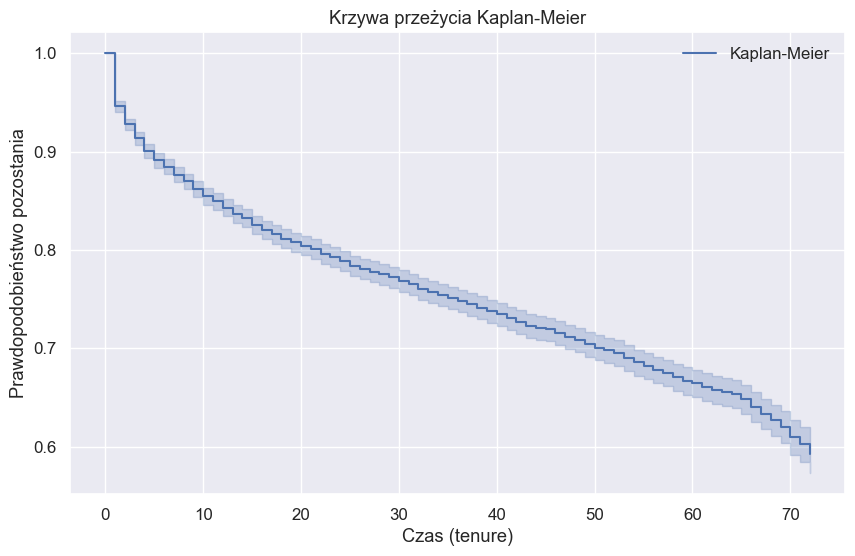

In [62]:
kmf = KaplanMeierFitter()

kmf.fit(durations=df['tenure'], event_observed=df['churn_num'], label='Kaplan-Meier')
kmf.plot()

plt.title('Krzywa przeżycia Kaplan-Meier')
plt.xlabel('Czas (tenure)')
plt.ylabel('Prawdopodobieństwo pozostania')
plt.show()


Korelacje wybranych zmiennych z czasem przeżycia:


,Zmienna,Korelacja z czasem przeżycia
0,totalcharges,0.82588
1,monthlycharges,0.24686
2,seniorcitizen,0.01568


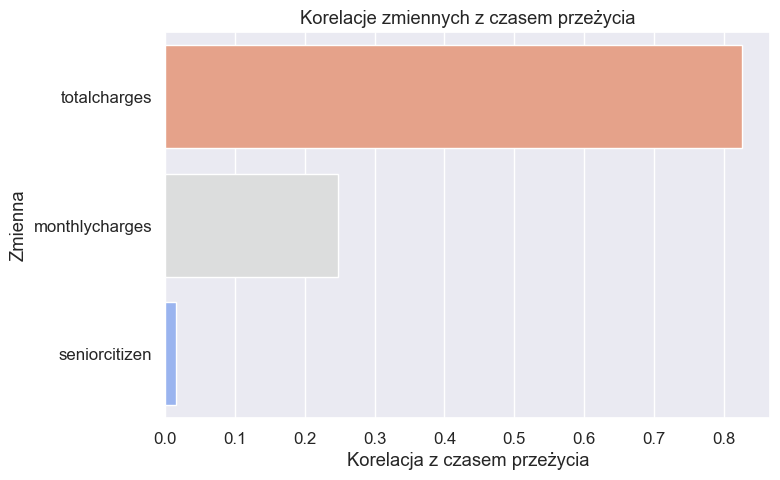

In [18]:
###  Zobrazowanie korelacji między zmiennymi a czasem przeżycia
selected_cols = ["gender","seniorcitizen","partner","dependents","tenure","multiplelines","internetservice","paperlessbilling","paymentmethod","monthlycharges","totalcharges"]
numeric_cols = df[selected_cols].select_dtypes(include=[np.number]).columns.tolist()
correlations = df[numeric_cols].corr()['tenure'].sort_values(ascending=False)
correlations = correlations.drop('tenure')

print("\nKorelacje wybranych zmiennych z czasem przeżycia:")
correlations_df = correlations.reset_index()
correlations_df.columns = ['Zmienna', 'Korelacja z czasem przeżycia']
display(correlations_df.style.background_gradient(cmap='coolwarm', subset=['Korelacja z czasem przeżycia']).format({'Korelacja z czasem przeżycia': '{:.5f}'}))

### Zobrazowanie korelacji jako wykres słupkowy i zapis do pliku PNG
plt.figure(figsize=(8, 5))
sns.barplot(
    data=correlations_df,
    y='Zmienna',
    x='Korelacja z czasem przeżycia',
    palette='coolwarm_r', # w sns "_r" oznacza odwrócenie kierunku palety kol
    orient='h'
)
plt.title('Korelacje zmiennych z czasem przeżycia')
plt.xlabel('Korelacja z czasem przeżycia')
plt.ylabel('Zmienna')
plt.tight_layout()
plt.savefig('correlations_with_time.png', dpi=150)
plt.show()


Krzywa K-M z przedziałami ufności


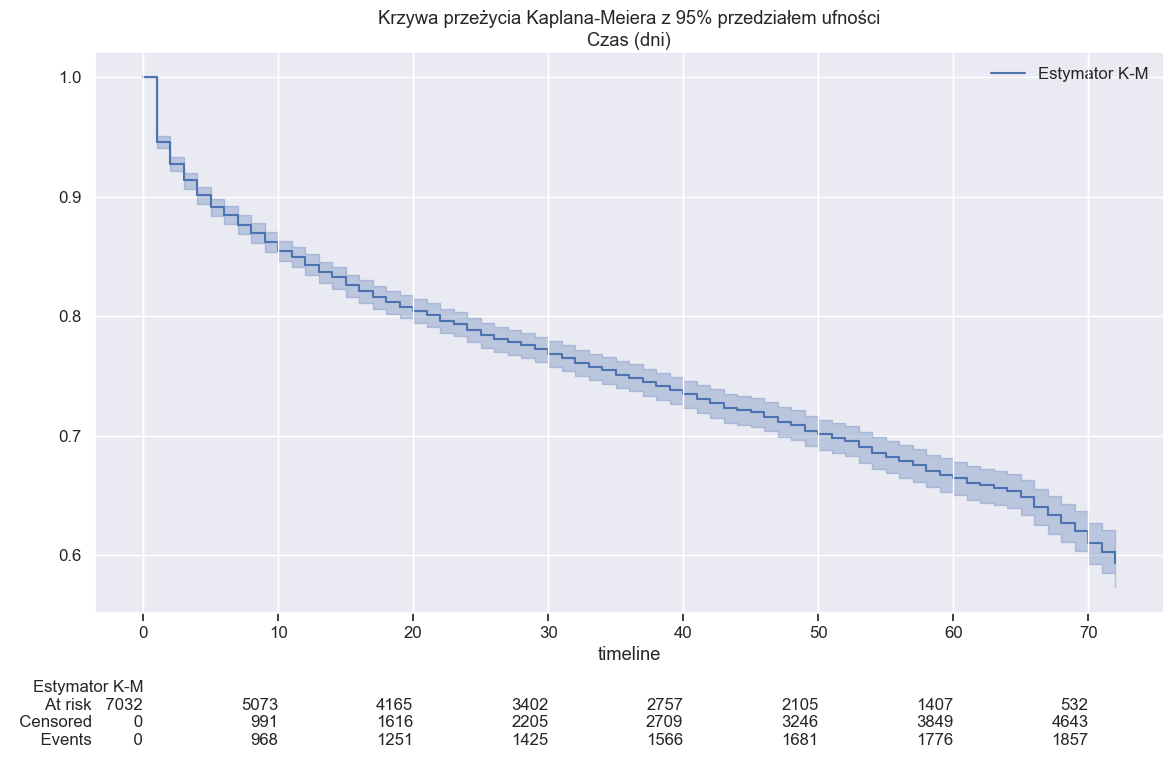

In [21]:
### Krzywa Kaplana-Meiera z przedziałami ufności
print("\nKrzywa K-M z przedziałami ufności")
plt.figure(figsize=(12, 8))
ax = plt.subplot(111)

# Wywołanie krzywej Kaplana-Meiera
kmf = KaplanMeierFitter()
kmf.fit(df['tenure'], df['churn_num'], label='Estymator K-M', alpha=0.05, )
kmf.plot(ax=ax, ci_show=True, ci_alpha=0.3)
# Dodanie tabeli osób narażonych na ryzyko
add_at_risk_counts(kmf, ax=ax)

plt.title('Krzywa przeżycia Kaplana-Meiera z 95% przedziałem ufności')
plt.xlabel('Czas (dni)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.grid(True)
plt.tight_layout()
plt.show()

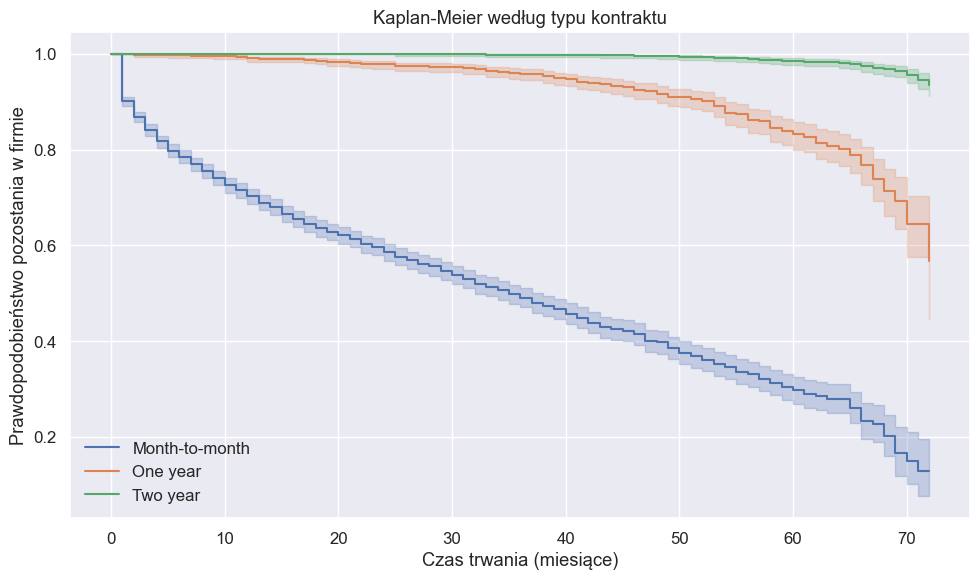

In [23]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

for grupa in df["contract"].dropna().unique():
    maska = df["contract"] == grupa
    kmf.fit(
        durations=df.loc[maska, "tenure"],
        event_observed=df.loc[maska, "churn_num"],
        label=grupa
    )
    kmf.plot_survival_function()

plt.title("Kaplan-Meier według typu kontraktu")
plt.xlabel("Czas trwania (miesiące)")
plt.ylabel("Prawdopodobieństwo pozostania w firmie")
plt.grid(True)
plt.tight_layout()
plt.show()

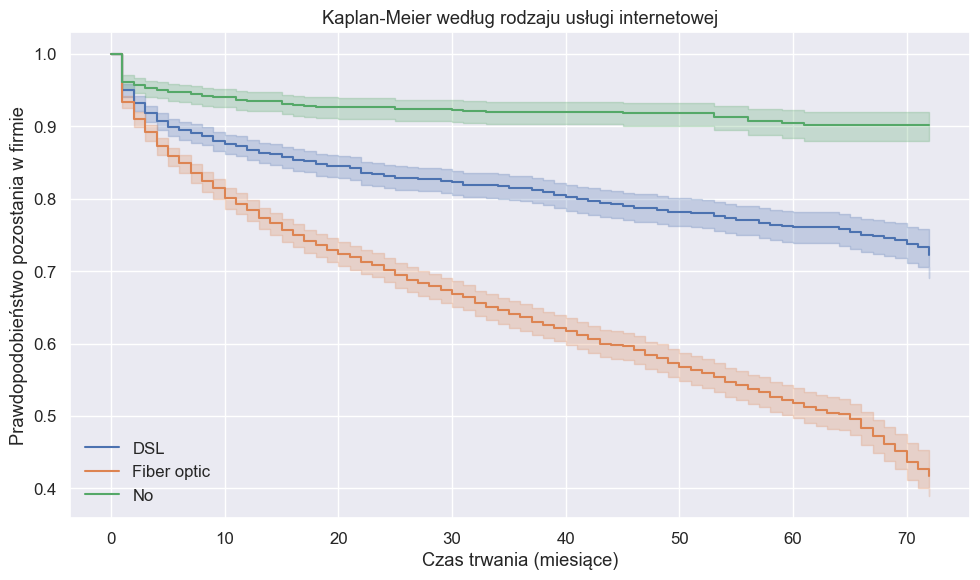

In [24]:
plt.figure(figsize=(10, 6))

for grupa in df["internetservice"].dropna().unique():
    maska = df["internetservice"] == grupa
    kmf.fit(
        durations=df.loc[maska, "tenure"],
        event_observed=df.loc[maska, "churn_num"],
        label=grupa
    )
    kmf.plot_survival_function()

plt.title("Kaplan-Meier według rodzaju usługi internetowej")
plt.xlabel("Czas trwania (miesiące)")
plt.ylabel("Prawdopodobieństwo pozostania w firmie")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
from lifelines.statistics import logrank_test

g1 = df["contract"] == "Month-to-month"
g2 = df["contract"] == "Two year"

wynik_lr = logrank_test(
    df.loc[g1, "tenure"],
    df.loc[g2, "tenure"],
    event_observed_A=df.loc[g1, "churn_num"],
    event_observed_B=df.loc[g2, "churn_num"]
)

print(wynik_lr)
print("p-value:", wynik_lr.p_value)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
        1550.51 <0.005       inf
p-value: 0.0


In [26]:
from lifelines.statistics import multivariate_logrank_test

wynik_multi = multivariate_logrank_test(
    df["tenure"],
    df["contract"],
    df["churn_num"]
)

print(wynik_multi)
print("p-value:", wynik_multi.p_value)

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
        2352.87 <0.005       inf
p-value: 0.0


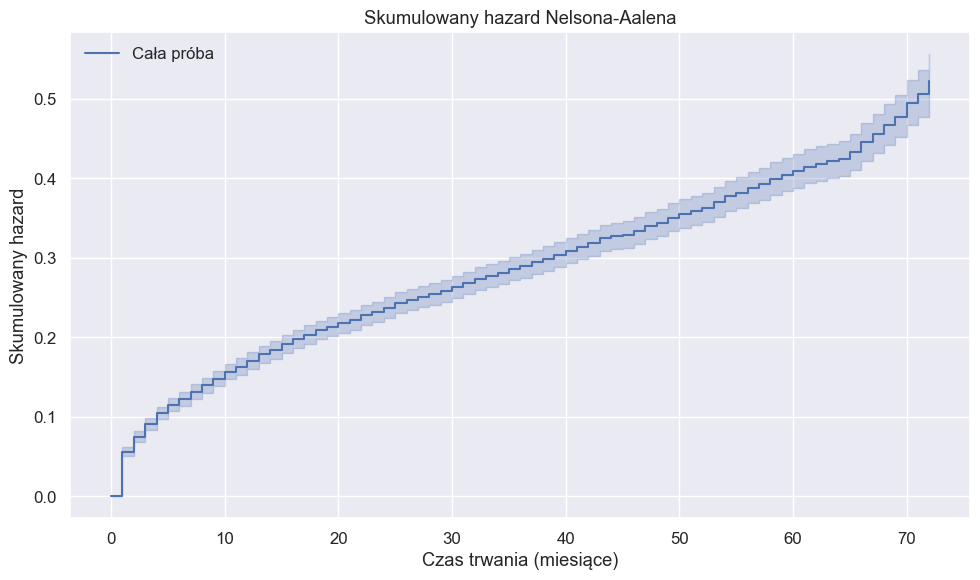

In [31]:
from lifelines import NelsonAalenFitter
import matplotlib.pyplot as plt

naf = NelsonAalenFitter()

plt.figure(figsize=(10, 6))
naf.fit(df["tenure"], event_observed=df["churn_num"], label="Cała próba")
naf.plot_cumulative_hazard()

plt.title("Skumulowany hazard Nelsona-Aalena")
plt.xlabel("Czas trwania (miesiące)")
plt.ylabel("Skumulowany hazard")
plt.grid(True)
plt.tight_layout()
plt.show()